In [2]:
import logging
import random
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
#全文过滤警告
import warnings
from sklearn.metrics import r2_score
import os
from torch.utils.data import Dataset,DataLoader
gpu = 0
use_cuda = gpu >= 0 and torch.cuda.is_available()
if use_cuda:
    torch.cuda.set_device(gpu)
    device = torch.device("cuda", gpu)
else:
    device = torch.device("cpu")
logging.info("Use cuda: %s, gpu id: %d.", use_cuda, gpu)

In [ ]:
class CNN_LSTM(nn.Module):   # CNN模型定义，继承nn.Module的模型类
    def __init__(self,n_filter,conv_input_channel,conv_output_channel, hidden_size, num_layers, output_size,dropout,training):
        super(CNN_LSTM, self).__init__() # 调用父类构造函数
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.conv_output_channel = conv_output_channel
        self.dropout = nn.Dropout(dropout)# Dropout层，用于防止过拟合
        #卷积核
        self.filter_sizes = [(x) for x in range(1,n_filter)]  # n-gram window
        # 3 个卷积层，卷积核大小分别为 [1,1], [2,1], [3,1]
        self.conv1 = nn.Sequential(
            nn.Conv1d(conv_input_channel, conv_output_channel, 
            kernel_size = self.filter_sizes[0]),nn.ReLU(),  # 输入通道、输出通道、卷积核大小，激活函数
            nn.MaxPool1d(kernel_size=6 - self.filter_sizes[0] + 1)) # 最大池化，核大小
        
        self.conv2 = nn.Sequential(
            nn.Conv1d(conv_input_channel, conv_output_channel, 
            kernel_size = self.filter_sizes[1]),nn.ReLU(),
            nn.MaxPool1d(kernel_size=6 - self.filter_sizes[1] + 1))
        
        self.conv3 = nn.Sequential(
            nn.Conv1d(conv_input_channel, conv_output_channel, 
            kernel_size = self.filter_sizes[2]),nn.ReLU(),
            nn.MaxPool1d(kernel_size=6 - self.filter_sizes[2] + 1))
        
    
        self.fc = nn.Sequential(nn.Linear(3*conv_output_channel+6,64),nn.ReLU(),      # 5层网络，逐步降维
                                nn.Linear(in_features=64,out_features=512),nn.ReLU(),
                                nn.Linear(in_features=512,out_features=64),nn.ReLU(),
                                nn.Linear(in_features=64,out_features=16),nn.ReLU(),
                                nn.Linear(16,output_size))
        self.training = training   # 开始训练，用于控制Dropout
    def forward(self, x):   #前向传播
        x = x.unsqueeze(1)  # 增加一个维度，用于卷积---[batch_size, 6] → [batch_size, 1, 6]
        x1 = self.conv1(x).permute(0,2,1)   # 卷积层并行处理，调整维度顺序
        x2 = self.conv2(x).permute(0,2,1)
        x3 = self.conv3(x).permute(0,2,1)
        #print('x1.shape',x2.shape,x1.shape,x.shape)
        reps = torch.cat([x,x1,x2,x3], dim=-1).squeeze() # 拼接，展平
        out = self.fc(reps)
        return out

data.shape (685200, 7)
test_data.shape (85650, 7)
(685200, 6) (85650, 6) (685200, 1) (85650, 1)


/opt/conda/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


epoch=1,675840of train, loss=0.011390186846256256
epoch=1	val_loss=0.009813211502178627  Validation loss decreased (inf --> 0.009813).  Saving model ...
epoch=2,675840of train, loss=0.004771066829562187
epoch=2	val_loss=0.003745141685666407  Validation loss decreased (0.009813 --> 0.003745).  Saving model ...
epoch=3,675840of train, loss=0.0013881910126656294
epoch=3	val_loss=0.0017832363099681541  Validation loss decreased (0.003745 --> 0.001783).  Saving model ...
epoch=4,675840of train, loss=0.0012680052313953638
epoch=4	val_loss=0.0010482381450642338  Validation loss decreased (0.001783 --> 0.001048).  Saving model ...
epoch=5,675840of train, loss=0.0007432044949382544
epoch=5	val_loss=0.0006842808044679902  Validation loss decreased (0.001048 --> 0.000684).  Saving model ...
epoch=6,675840of train, loss=0.000445848039817065
epoch=6	val_loss=0.000508439920582425  Validation loss decreased (0.000684 --> 0.000508).  Saving model ...
epoch=7,675840of train, loss=0.0003172682481817901


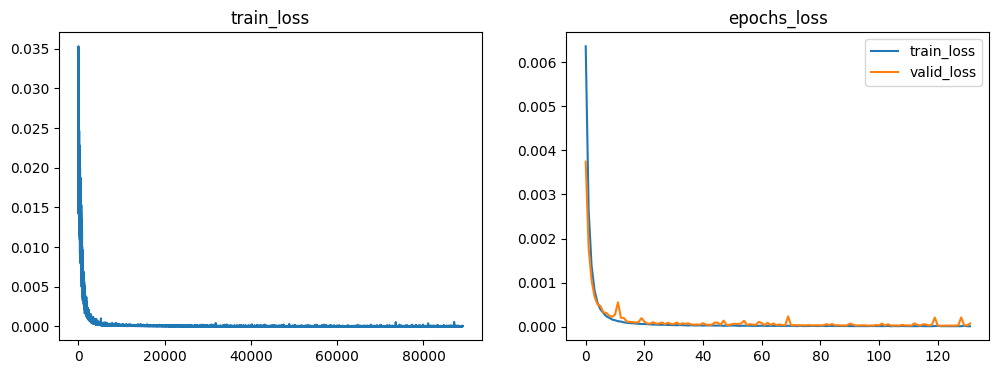

pred.shape: (51390, 1)
r2_score=0.9988


In [ ]:
# 数据加载和训练辅助类
class MyDataset(Dataset):  # 自定义数据集类，用于dataloader
    def __init__(self,x,y): # 构造函数，接受xy
        self.x = x   # 存储x
        self.y = y   

    def __getitem__(self, index):     # 实现索引访问，PyTorch接口
        return self.x[index],self.y[index]   # 返回指定索引的特征和目标数据对

    def __len__(self):   # 返回数据集大小
        # You should change 0 to the total size of your dataset.
        return len(self.x)  

class EarlyStopping():  # 早停机制，防止过拟合
    def __init__(self,patience=7,verbose=False,delta=0):  # 容忍度，是否打印，阈值
        self.patience = patience  # 容忍度
        self.verbose = verbose    # 是否打印
        self.counter = 0          # 计数器  
        self.best_score = None    # 最佳得分    
        self.early_stop = False   # 早停标志    
        self.val_loss_min = np.Inf # 最小验证损失
        self.delta = delta        # 改善阈值，只有超过这个阈值才认为是真正改善    
    def __call__(self,val_loss,model,path):   # 使对象可以像函数一样调用
        print("val_loss={}".format(val_loss),end = '  ') # 当前轮数的验证损失
        score = -val_loss  # 转换为正数，越大越好
        if self.best_score is None:  # 第一处调用，初始化最佳分数并保存模型。。。如果还没有最佳得分
            self.best_score = score  # 更新最佳得分
            self.save_checkpoint(val_loss,model,path)  # 保存模型
        elif score < self.best_score+self.delta:  # 损失没有改善，计数器增加，如果达到容忍轮数则早停。
            self.counter+=1  # 计数器加1    
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter>=self.patience:
                self.early_stop = True
        else:                     # 损失有改善，更新最佳分数，保存模型，重置计数器
            self.best_score = score
            self.save_checkpoint(val_loss,model,path)
            self.counter = 0
    def save_checkpoint(self,val_loss,model,path):    #保存检查点
        if self.verbose:
            print(
                f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), path+'Lstm.pth')  # 保存模型
        self.val_loss_min = val_loss  # 更新最小验证损失
def loss_picture(train_loss, train_epochs_loss, valid_epochs_loss):  # 绘制损失曲线
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss[:])
    plt.title("train_loss")
    plt.subplot(1, 2, 2)
    plt.plot(train_epochs_loss[1:], label="train_loss")
    plt.plot(valid_epochs_loss[1:], label="valid_loss")
    plt.title("epochs_loss")
    plt.legend()
    plt.show()
# 训练函数和数据处理
def train2(train_dataloader,test_dataloader,epochs,
           optimizer,model,criterion,early_stopping,batch_size):  # 主要训练函数，包含完整的训练循环
    train_epochs_loss = [] # 训练数据加载器
    valid_epochs_loss = [] # 测试数据加载器
    train_loss = []
    valid_loss = []
    for epoch in range(1,epochs+1): 
        logging.info("--"*10)
        model.train()
        train_epoch_loss = []
        for idx,(x,y) in enumerate(train_dataloader,1):
            data_x = x.to(torch.float32).to(device)
            data_y = y.to(torch.float32).to(device)
            #print('data_y.shape,data_x.shape',data_y.shape,data_x.shape)
            optimizer.zero_grad()
            outputs = model(data_x)

            loss = criterion(data_y, outputs)
            loss.backward()
            optimizer.step()
            train_epoch_loss.append(loss.item())
            train_loss.append(loss.item())
            if idx % (660) == 0:# (len(train_data) // 10)
                print("epoch={},{}of train, loss={}".format(
                    epoch, idx*batch_size, loss.item()))
        train_epochs_loss.append(np.average(train_epoch_loss))

        # =====================valid============================
        model.eval()
        valid_epoch_loss = []
        with torch.no_grad():
            for idx,(x,y) in enumerate(test_dataloader,1):
                data_x = x.to(torch.float32).to(device)
                data_y = y.to(torch.float32).to(device)
                outputs = model(data_x)
                loss = criterion(data_y, outputs)
                valid_epoch_loss.append(loss.item())
                valid_loss.append(loss.item())
        valid_epochs_loss.append(np.average(valid_epoch_loss))

        # ==================early stopping======================
        print(f"epoch={epoch}",end='\t')
        early_stopping(valid_epochs_loss[-1], model=model, path=r'./')
        if early_stopping.early_stop:
            print("Early stopping")
            break
         # ====================adjust lr========================
#         lr_adjust = {5: 0.001, 10: 0.0001}
#         if epoch in lr_adjust:
#             lr = lr_adjust[epoch]
#             for param_group in optimizer.param_groups:
#                 param_group['lr'] = lr
#             print('Updating learning rate to {}'.format(lr))

        # ====================adjust lr========================
    loss_picture(train_loss, train_epochs_loss, valid_epochs_loss)

def min_max(parameters,test_parameters):
    min_value = parameters.min(axis=0)
    ptp_value = parameters.ptp(axis=0)
    X = (parameters-min_value)/ptp_value
    test_x = (test_parameters - min_value) /ptp_value
    return X,test_x
def test():
    data = np.loadtxt('/kaggle/input/parahzabsorb/train_ParaHzAbsorb.txt')
    print('data.shape', data.shape)
    x_train = data[:, 0:6]
    y_train = data[:, 6:7]

    test_data = np.loadtxt('/kaggle/input/parahzabsorb/test_ParaHzAbsorb.txt')
    print('test_data.shape', test_data.shape)
    x_test = test_data[:, 0:6]
    y_test = test_data[:, 6:7]
    print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)
    
    x_test,x_val,y_test,y_val = train_test_split(x_test,y_test,random_state=0,test_size=0.4,shuffle=True)

    x_train_scaler,x_test_scaler= min_max(x_train,x_test)
    y_train_scaler, y_test_scaler= min_max(y_train, y_test)
    _,x_val_scaler= min_max(x_train,x_val)
    _,y_val_scaler= min_max(y_train, y_val)

    batch_size = 1024
    train_dataset = MyDataset(x_train_scaler,y_train_scaler)
    train_dataloader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=8)
    
    val_dataset = MyDataset(x_val_scaler, y_val_scaler)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,num_workers=8)
    
#=============================================================================================
    # =========================cnn_lstm parameter========================================
    filter_size, conv_input_channel, conv_output_channel = 4, 1, 4  # cnn
    hidden_size, num_layers = 100, 2  # LSTM
    output_size = len(y_test[0])  # Fnn
    dropout = 0.15
    training = True
    model = CNN_LSTM(filter_size, conv_input_channel, conv_output_channel,
                     hidden_size, num_layers, output_size, dropout, training)
    model.to(device)
    # =========================init========================================
    # 设置损失函数,这里使用的是均方误差损失
    criterion = nn.MSELoss()
    # 设置优化函数和学习率lr
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, betas=(0.9, 0.999), eps=1e-8,weight_decay=0)#
    # 设置训练周期
    epochs = 1000
    patience = 10 # 早停迭代次数

    early_stopping = EarlyStopping(patience=patience, verbose=True)
    # ================================================================
    train2(train_dataloader,val_dataloader,epochs,
          optimizer, model, criterion, early_stopping, batch_size)
    # =============================predict=========================================
    model.load_state_dict(torch.load('./Lstm.pth'))
    # pre = model_predict(model, x_test, y_test, scaler_x, scaler_y)

    test_dataset = MyDataset(x_test_scaler, y_test_scaler)
    test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    y_pred = []
    with torch.no_grad():
        for idx, (x,y) in enumerate(test_dataloader, 1):
            data_x = x.to(torch.float32).to(device)
            y_pred.append(model(data_x).reshape(-1, ).cpu())
    logging.info('===========================================')
    pred = np.array(y_pred) * y_train.ptp(axis=0) + y_train.min(axis = 0)
    print('pred.shape:',pred.shape)
    print('r2_score=%.4f' % (r2_score(y_test, pred)))
    
    
    
test()

In [4]:
data = np.loadtxt('/kaggle/input/parahzabsorb/train_ParaHzAbsorb.txt')
print('data.shape', data.shape)
x_train = data[:, 0:6]
y_train = data[:, 6:7]

virtual_data = np.loadtxt('/kaggle/input/virtual-600-x/virtual_train.txt')
print('test_data.shape', virtual_data.shape)
x_test = virtual_data[:, 0:6]
y_test = np.array([i for i in range(virtual_data.shape[0])])
print(x_train.shape, x_test.shape, y_train.shape,y_test.shape)

x_train_scaler,x_test_scaler= min_max(x_train,x_test)

#=============================================================================================
# =========================cnn_lstm parameter========================================
filter_size, conv_input_channel, conv_output_channel = 4, 1, 2  # cnn
hidden_size, num_layers = 100, 2  # LSTM
output_size = len(y_train[0])  # Fnn
dropout = 0.15
training = True
model = CNN_LSTM(filter_size, conv_input_channel, conv_output_channel,
                 hidden_size, num_layers, output_size, dropout, training)
model.to(device)
# =========================init========================================
model.load_state_dict(torch.load('./Lstm.pth'))
# pre = model_predict(model, x_test, y_test, scaler_x, scaler_y)
test_dataset = MyDataset(x_test_scaler, y_train)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)
y_pred = []
with torch.no_grad():
    for idx, (x,y) in enumerate(test_dataloader, 1):
        data_x = x.to(torch.float32).to(device)
        y_pred.append(model(data_x).reshape(-1, ).cpu())
logging.info('===========================================')
pred = np.array(y_pred) * y_train.ptp(axis=0) + y_train.min(axis = 0)
print('pred.shape:',pred.shape)
#print('r2_score=%.4f' % (r2_score(y_test, pred)))

data.shape (685200, 7)
test_data.shape (342600, 6)
(685200, 6) (342600, 6) (685200, 1) (342600,)
pred.shape: (342600, 1)


In [5]:
y = pred.reshape(600,-1)

In [7]:
np.savetxt('./virtual_y.txt',y)